# LAB 7 —  Object Detection

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:**

## Learning objectives
**Context:** you will fine-tune a small YOLO detector on a small blood-cell dataset and analyze the results.


## Dataset
We will use the **BCCD Blood Cell Detection Dataset**, which contains microscope images with bounding-box annotations for:

- `RBC` — red blood cells
- `WBC` — white blood cells
- `Platelets`



>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


# 0. Installation


In [1]:
!pip install -q ultralytics opencv-python matplotlib pyyaml lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00


# 1. Imports and hardware configuration

This cell automatically selects GPU if available.  
If you want to force CPU mode, set `FORCE_CPU = True`.

In [2]:
from pathlib import Path
import os
import random
import shutil
import zipfile
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FORCE_CPU = False

if torch.cuda.is_available() and not FORCE_CPU:
    DEVICE = 0
    HARDWARE = "GPU"
else:
    DEVICE = "cpu"
    HARDWARE = "CPU"

print("Hardware mode:", HARDWARE)
print("Training device:", DEVICE)

if HARDWARE == "GPU":
    IMG_SIZE = 416
    EPOCHS = 15
    BATCH = 8
    MAX_IMAGES = 160
else:
    IMG_SIZE = 320
    EPOCHS = 3
    BATCH = 2
    MAX_IMAGES = 80

print(f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH={BATCH}, MAX_IMAGES={MAX_IMAGES}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hardware mode: GPU
Training device: 0
IMG_SIZE=416, EPOCHS=15, BATCH=8, MAX_IMAGES=160


# 2. Download the dataset

We download BCCD from GitHub.  
The original annotations are in **Pascal VOC XML format**, so we will convert them to **YOLO format** later.

Expected original structure:

```text
BCCD/
├── Annotations/
├── JPEGImages/
└── ImageSets/
```

In [3]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKDIR = ROOT / "object_detection_tp"
RAW_DIR = WORKDIR / "raw_bccd"
YOLO_DIR = WORKDIR / "bccd_yolo"

WORKDIR.mkdir(parents=True, exist_ok=True)

url = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"
zip_path = WORKDIR / "bccd_master.zip"

if not zip_path.exists():
    print("Downloading BCCD dataset...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("Zip file already exists.")

if not RAW_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(WORKDIR)
    extracted = WORKDIR / "BCCD_Dataset-master" / "BCCD"
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in extracted.iterdir():
        shutil.copytree(item, RAW_DIR / item.name, dirs_exist_ok=True)
else:
    print("Raw dataset already exists.")

print("RAW_DIR:", RAW_DIR)
print("Number of images:", len(list((RAW_DIR / "JPEGImages").glob("*.jpg"))))
print("Number of annotations:", len(list((RAW_DIR / "Annotations").glob("*.xml"))))

Extracting dataset...
RAW_DIR: /content/object_detection_tp/raw_bccd
Number of images: 364
Number of annotations: 364


# 3. Understand annotation formats

## 3.1 Pascal VOC format

The original dataset uses XML files. A bounding box is stored as:

```text
xmin, ymin, xmax, ymax
```

These are pixel coordinates.

## 3.2 YOLO format

YOLO expects one `.txt` file per image. Each row has:

```text
class_id x_center y_center width height
```

Important: YOLO coordinates are **normalized** between 0 and 1.

Example:

```text
1 0.52 0.43 0.20 0.30
```

This means:

- class ID = 1
- center x = 52% of image width
- center y = 43% of image height
- box width = 20% of image width
- box height = 30% of image height

# 4. Convert BCCD annotations to YOLO format

The following cells create the YOLO-compatible dataset structure:

```text
bccd_yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```


In [4]:
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def voc_box_to_yolo(box, img_w, img_h):
    """
    Convert a Pascal VOC box [xmin, ymin, xmax, ymax] in pixels
    to YOLO normalized format [x_center, y_center, width, height].
    """
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

def parse_voc_xml(xml_path):
    """Parse one Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_TO_ID:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "class_id": CLASS_TO_ID[class_name],
            "box_xyxy": [xmin, ymin, xmax, ymax],
            "box_yolo": voc_box_to_yolo([xmin, ymin, xmax, ymax], img_w, img_h)
        })

    return img_w, img_h, objects

In [5]:
def prepare_yolo_dataset(max_images=160, train_ratio=0.70, val_ratio=0.20):
    # Remove previous converted dataset to keep the notebook reproducible 😉
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)

    for split in ["train", "val", "test"]:
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_paths = sorted((RAW_DIR / "JPEGImages").glob("*.jpg"))
    image_paths = image_paths[:max_images]
    random.shuffle(image_paths)

    n = len(image_paths)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)

    splits = {
        "train": image_paths[:n_train],
        "val": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    split_counts = {}
    class_counter = Counter()

    for split, paths in splits.items():
        split_counts[split] = len(paths)

        for img_path in paths:
            xml_path = RAW_DIR / "Annotations" / f"{img_path.stem}.xml"
            img_w, img_h, objects = parse_voc_xml(xml_path)

            # Copy image
            dst_img = YOLO_DIR / "images" / split / img_path.name
            shutil.copy2(img_path, dst_img)

            # Write YOLO label
            label_path = YOLO_DIR / "labels" / split / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                for obj in objects:
                    class_counter[obj["class_name"]] += 1
                    x_center, y_center, width, height = obj["box_yolo"]
                    f.write(
                        f"{obj['class_id']} "
                        f"{x_center:.6f} {y_center:.6f} "
                        f"{width:.6f} {height:.6f}\n"
                    )

    data_yaml = {
        "path": str(YOLO_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    with open(YOLO_DIR / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return split_counts, class_counter

split_counts, class_counter = prepare_yolo_dataset(MAX_IMAGES)

print("YOLO dataset created at:", YOLO_DIR)
print("Split counts:", split_counts)
print("Object counts:", class_counter)

print("\nData YAML:")
print((YOLO_DIR / "data.yaml").read_text())

YOLO dataset created at: /content/object_detection_tp/bccd_yolo
Split counts: {'train': 112, 'val': 32, 'test': 16}
Object counts: Counter({'RBC': 1945, 'Platelets': 187, 'WBC': 165})

Data YAML:
path: /content/object_detection_tp/bccd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: RBC
  1: WBC
  2: Platelets



# 5. Dataset sanity check

Before training any model, always inspect the dataset.

## Questions

Answer these in your notebook:

1. How many images are in the train, validation, and test sets?
2. How many classes are there?
3. Which class appears the most?
4. Which class appears the least?
5. Why can class imbalance be a problem for object detection?

In [6]:
# TODO :
# Print the number of images in each split.
# Print the number of label files in each split.
# Print the object counts per class.

for split in ["train", "val", "test"]:
  num_images = len(list((YOLO_DIR / "images" / split).glob("*.jpg")))
  num_labels = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
  print(f"{split.capitalize()} images: {num_images}")
  print(f"{split.capitalize()} labels: {num_labels}")


print("\nObject counts per class:")
for class_name, count in class_counter.items():
    print(f"- {class_name} : {count}")



# TODO:
# Write 2-3 sentences below as a Markdown cell explaining whether the dataset is balanced.

Train images: 112
Train labels: 112
Val images: 32
Val labels: 32
Test images: 16
Test labels: 16

Object counts per class:
- RBC : 1945
- WBC : 165
- Platelets : 187


Answer: The dataset isn't balanced. Red blood cells (RBC) generally make up the vast majority of the cells, compared to white blood cells (WBC) and platelets. This imbalance can cause the model to perform very well on the majority class but to underdetect the minority classes.


Answer:
1. How many images are in the train, validation, and test sets?
There are 112 images in the training set, 32 images in the validation set and 16 images in the test set.

2. How many classes are there?
There are 3 classes in this dataset: RBC (Red Blood Cells), WBC (White Blood Cells) and Platelets.

3. Which class appears the most?
The RBC class appears the most with 1945 occurrences.

4. Which class appears the least?
The WBC class with only 165 occurrences.

5. Why can class imbalance be a problem for object detection?
Because the model sees too many Red Blood Cells (RBC) and not enough White Blood Cells (WBC) or Plateletes. As a result, it gets really good at finding RBCs, but it will often miss or misidentify the rare cells.

# 6. Visualize YOLO labels

The function below converts YOLO normalized boxes back to pixel coordinates and draws them.

In [7]:
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized box to pixel box [xmin, ymin, xmax, ymax].

    TODO 2:
    Complete this function.

    Hints:
    xmin = (x_center - width / 2) * img_w
    """

    # TODO: replace the next line with your implementation

    xmin = (x_center - width / 2) * img_w
    ymin = (y_center - height / 2) * img_h
    xmax = (x_center + width / 2) * img_w
    ymax = (y_center + height / 2) * img_h
    return xmin, ymin, xmax, ymax

Sample image: BloodImage_00152.jpg


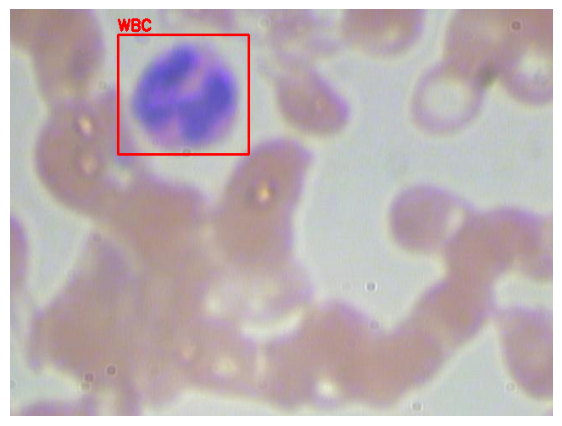

In [8]:
def load_yolo_labels(label_path):
    labels = []
    if not Path(label_path).exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            labels.append([class_id, x_center, y_center, width, height])
    return labels

def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    labels = load_yolo_labels(label_path)

    for class_id, x_center, y_center, width, height in labels:
        xmin, ymin, xmax, ymax = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[class_id],
            (xmin, max(20, ymin - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# After completing yolo_to_xyxy, run this cell
sample_image = random.choice(list((YOLO_DIR / "images" / "train").glob("*.jpg")))
sample_label = YOLO_DIR / "labels" / "train" / f"{sample_image.stem}.txt"

print("Sample image:", sample_image.name)
draw_yolo_labels(sample_image, sample_label)

## Questions

1. Are the boxes well aligned with the objects?
2. Which objects are small?
3. Which objects are close to each other?
4. Which class do you think will be hardest for YOLO to detect? Why?

Answer:
1. Yes, the bounding box is well aligned.

2. Platelets are the smallest objects in this dataset. Compared to the White Blood Cells and Red Blood Cells. They appear as tiny dots on the slides.

3. Red Blood Cells (RBC) are very close to each other. Because they are so abundant, they frequently touch and form dense clusters across the image.

4. Platelets will be the hardest because they are so small that the network might just miss them. Another big challenge is the Red Blood Cells (RBCs), because they overlap and clump together so much that it's hard to draw a separate box for each one.

# 7.  IoU

IoU means **Intersection over Union**.

It measures how much a predicted box overlaps with a ground-truth box.

```text
IoU = area(intersection) / area(union)
```


# 8. Implement IoU

Complete the function below.

Input boxes use the pixel format:

```text
[xmin, ymin, xmax, ymax]
```

In [9]:
def compute_iou(box_a, box_b):
    """
    Compute IoU between two boxes.

    box_a and box_b are in [xmin, ymin, xmax, ymax] format.

    TODO :
    Complete the implementation.
    """
    # TODO: compute intersection coordinates
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    # TODO: compute intersection width and height
    inter_w = max(0, x_right - x_left)
    inter_h = max(0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    # TODO: compute each box area
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    # TODO: compute union
    union = area_a + area_b - inter_area

    # TODO: return IoU
    return inter_area / union if union > 0 else 0.0

In [10]:
# Test your IoU function

box_a = [50, 50, 150, 150]
box_b = [100, 100, 200, 200]

iou = compute_iou(box_a, box_b)
print("IoU:", iou)

# Expected value: approximately 0.1429
assert abs(iou - 0.1429) < 1e-3, "IoU is not correct. Check your implementation."

IoU: 0.14285714285714285


# 9. Load a small YOLO model

The model starts from pretrained weights.  

In [11]:
# YOLOv8 nano is small
# If your environment uses a newer Ultralytics model naming convention,
# you may replace "yolov8n.pt" with another nano model available in your setup.

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

# 10. Inference before fine-tuning

Before training on BCCD, test the pretrained model.

## Questions

1. Does the pretrained model already detect RBC, WBC, or Platelets?
2. Why or why not?
3. What classes was the pretrained model probably trained on?

Answer:

1. No, it doesn't detect these specific cells correctly.

2. Because the pretrained weights were learned on a general dataset, not microscopic medical images. Since the model has never been trained on RBCs, WBCs or Platelets, it lacks the necessary features to recognize them.

3. It was trained on the COCO dataset, which consists of objects like "person", "car", "dog", "chair"...

Testing pretrained model on: /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00124.jpg: 480x640 1 person, 337.0ms
Speed: 5.7ms preprocess, 337.0ms inference, 115.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


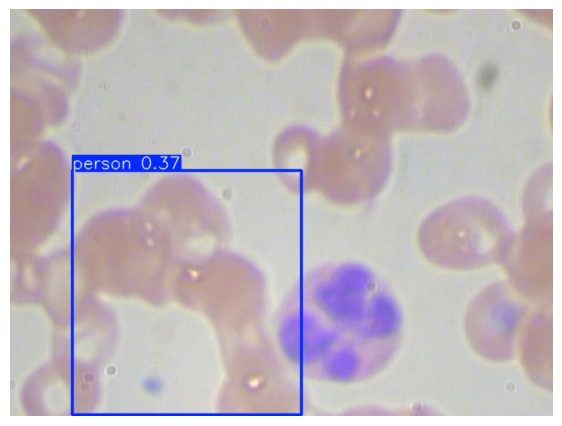

In [12]:
test_image = random.choice(list((YOLO_DIR / "images" / "test").glob("*.jpg")))
print("Testing pretrained model on:", test_image)

pre_results = model.predict(
    source=str(test_image),
    conf=0.25,
    device=DEVICE,
    save=True
)

# Display the saved prediction
pred_img = Path(pre_results[0].save_dir) / test_image.name
if pred_img.exists():
    img = cv2.imread(str(pred_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Prediction image was not found. Check Ultralytics output directory:", pre_results[0].save_dir)

# 11. Train YOLO on the custom dataset

This cell uses the configuration selected earlier.

You can reduce `EPOCHS` if the runtime is too long.

In [13]:
data_yaml_path = YOLO_DIR / "data.yaml"

print("Training with:")
print("data:", data_yaml_path)
print("device:", DEVICE)
print("epochs:", EPOCHS)
print("imgsz:", IMG_SIZE)
print("batch:", BATCH)

train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,
    name="bccd_yolo_tp",
    exist_ok=True
)

Training with:
data: /content/object_detection_tp/bccd_yolo/data.yaml
device: 0
epochs: 15
imgsz: 416
batch: 8
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_tp/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

# 12. Validate the trained model

Validation gives detection metrics such as precision, recall, and mAP.

Do not worry if the score is not very high.  
This is a small dataset and short training.

In [14]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0
)

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1015.8±251.1 MB/s, size: 19.8 KB)
val: Scanning /content/object_detection_tp/bccd_yolo/labels/val.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 13.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.3it/s 1.2s
                   all         32        474      0.752      0.816      0.791        0.5
                   RBC         31        411      0.653      0.843      0.789      0.492
                   WBC         29         30      0.883          1      0.971       0.75
             Platelets         19         33      0.721      0.606      0.615       0.26
Speed: 1.3ms preprocess, 9.4ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to /content/runs/detect/val

In [15]:
# Reload the best fine-tuned weights explicitly
best_weights = Path("/content/runs/detect/bccd_yolo_tp/weights/best.pt")
model = YOLO(str(best_weights))
print("Loaded fine-tuned model from:", best_weights)

Loaded fine-tuned model from: /content/runs/detect/bccd_yolo_tp/weights/best.pt


# 13. Run inference after fine-tuning

Now test the fine-tuned model on images it did not train on.

In [16]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*.jpg"))
print("Number of test images:", len(test_images))

results = model.predict(
    source=[str(p) for p in test_images[:5]],
    conf=0.25,
    imgsz=IMG_SIZE,
    device=DEVICE,
    save=True
)

print("Saved predictions to:", results[0].save_dir)

Number of test images: 16

0: 320x416 17 RBCs, 1 WBC, 7.8ms
1: 320x416 11 RBCs, 1 WBC, 7.8ms
2: 320x416 18 RBCs, 1 WBC, 7.8ms
3: 320x416 17 RBCs, 1 WBC, 1 Platelets, 7.8ms
4: 320x416 17 RBCs, 1 WBC, 1 Platelets, 7.8ms
Speed: 0.9ms preprocess, 7.8ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2
Saved predictions to: /content/runs/detect/predict-2


In [17]:
# Display saved predictions
save_dir = Path(results[0].save_dir)

for img_path in test_images[:5]:
    pred_path = save_dir / img_path.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

# 14. Confidence threshold experiment

YOLO outputs detections with confidence scores.

If the threshold is low, the model keeps more boxes.  
If the threshold is high, the model keeps fewer boxes.

## Exercise

Try several confidence thresholds.

Experiment image: BloodImage_00006.jpg

Running prediction with conf=0.1

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 28 RBCs, 1 WBC, 47.4ms
Speed: 1.2ms preprocess, 47.4ms inference, 2.1ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2


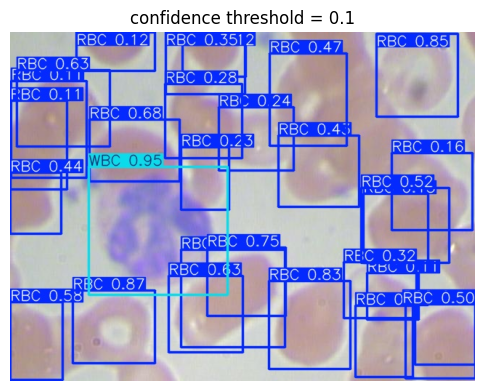


Running prediction with conf=0.3

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 16 RBCs, 1 WBC, 12.2ms
Speed: 2.0ms preprocess, 12.2ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2


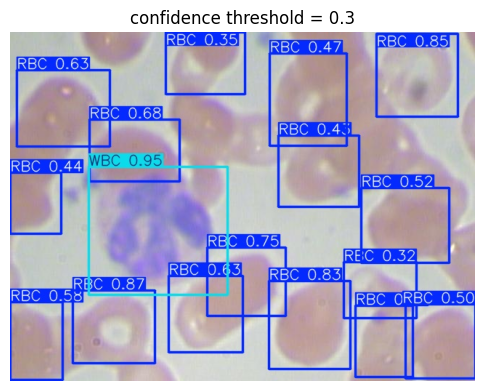


Running prediction with conf=0.5

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 10 RBCs, 1 WBC, 12.5ms
Speed: 1.8ms preprocess, 12.5ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2


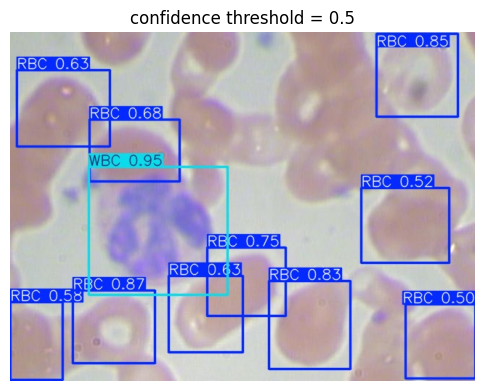


Running prediction with conf=0.8

image 1/1 /content/object_detection_tp/bccd_yolo/images/test/BloodImage_00006.jpg: 320x416 3 RBCs, 1 WBC, 10.1ms
Speed: 2.0ms preprocess, 10.1ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2


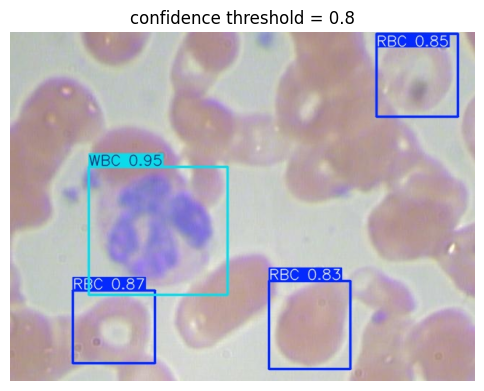

In [18]:
# TODO
# Add at least four confidence thresholds.
confidence_thresholds = [0.1, 0.3, 0.5, 0.8] # TODO

experiment_image = random.choice(test_images)
print("Experiment image:", experiment_image.name)

for conf in confidence_thresholds:
    print(f"\nRunning prediction with conf={conf}")
    pred = model.predict(
        source=str(experiment_image),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save=True
    )

    pred_path = Path(pred[0].save_dir) / experiment_image.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"confidence threshold = {conf}")
        plt.axis("off")
        plt.show()


TODO: Answer.

1. What happens when the confidence threshold is very low?
2. What happens when the confidence threshold is very high?
3. Which threshold gives the best visual result on your image?
4. How does confidence threshold affect false positives?
5. How does confidence threshold affect false negatives?

Answer:

1. We get too many boxes. The model detects background noise and creates a lot of overlapping boxes.

2. We get almost no boxes. The model becomes too strict and filters out even the real cells.

3. A threshold around 0.3 or 0.5 gives the best result. It keeps the real cells and removes the bad predictions.

4. A lower confidence threshold increases false positives (it guesses too much).

5. A higher confidence threshold increases false negatives (it ignores real cells).

# 15. Compare predictions with ground truth using IoU

We will now compare model predictions to ground-truth boxes.

A prediction is usually considered correct if:

```text
class is correct AND IoU >= 0.5
```

This is a simplified evaluation, not full mAP.

In [19]:
def get_ground_truth_boxes(image_path):
    label_path = YOLO_DIR / "labels" / "test" / f"{image_path.stem}.txt"
    labels = load_yolo_labels(label_path)

    image = cv2.imread(str(image_path))
    img_h, img_w = image.shape[:2]

    gt = []
    for class_id, x_center, y_center, width, height in labels:
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        gt.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "box": list(map(float, box))
        })
    return gt

def get_prediction_boxes(image_path, conf=0.25):
    pred = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []
    if pred.boxes is None:
        return detections

    for box, cls, score in zip(pred.boxes.xyxy.cpu().numpy(),
                               pred.boxes.cls.cpu().numpy(),
                               pred.boxes.conf.cpu().numpy()):
        class_id = int(cls)
        detections.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id),
            "confidence": float(score),
            "box": box.tolist()
        })
    return detections

In [20]:
# TODO 5:
# Complete a simple matching procedure.
#
# For each prediction:
# 1. Compare it with every ground-truth box of the same class.
# 2. Compute IoU.
# 3. Keep the maximum IoU.
# 4. Mark it as correct if max IoU >= 0.5.

eval_image = random.choice(test_images)
gt_boxes = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print("Image:", eval_image.name)
print("Ground truth boxes:", len(gt_boxes))
print("Predicted boxes:", len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    # TODO: compare pred with gt boxes of the same class
    for gt in gt_boxes:
         if pred["class_id"] == gt["class_id"]:
             iou = compute_iou(pred["box"], gt["box"])
             if iou > best_iou:
                best_iou = iou

    status = "correct" if best_iou >= 0.5 else "incorrect"
    # TODO: set status to "correct" if best_iou >= 0.5, otherwise "incorrect"

    print(
        f"Prediction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, best IoU={best_iou:.3f}, status={status}"
    )

Image: BloodImage_00058.jpg
Ground truth boxes: 10
Predicted boxes: 15
Prediction 0: class=RBC, conf=0.90, best IoU=0.859, status=correct
Prediction 1: class=WBC, conf=0.89, best IoU=0.876, status=correct
Prediction 2: class=RBC, conf=0.87, best IoU=0.933, status=correct
Prediction 3: class=RBC, conf=0.67, best IoU=0.775, status=correct
Prediction 4: class=RBC, conf=0.50, best IoU=0.770, status=correct
Prediction 5: class=RBC, conf=0.44, best IoU=0.077, status=incorrect
Prediction 6: class=RBC, conf=0.43, best IoU=0.792, status=correct
Prediction 7: class=RBC, conf=0.39, best IoU=0.603, status=correct
Prediction 8: class=RBC, conf=0.35, best IoU=0.258, status=incorrect
Prediction 9: class=RBC, conf=0.35, best IoU=0.605, status=correct
Prediction 10: class=RBC, conf=0.32, best IoU=0.803, status=correct
Prediction 11: class=RBC, conf=0.31, best IoU=0.073, status=incorrect
Prediction 12: class=RBC, conf=0.28, best IoU=0.773, status=correct
Prediction 13: class=RBC, conf=0.27, best IoU=0.5

## Questions

1. Can a high-confidence prediction still be incorrect?
2. Can a box be well localized but have the wrong class?

1. Yes. The model can be very confident but still draw a bad bounding box or detect background noise instead of a real cell.

2. Yes. Finding the object and classifying it are two different things. The model could draw a perfect box around a White Blood Cell but mistakenly label it as a Red Blood Cell.

# 16. Non-Maximum Suppression intuition

Object detectors often predict multiple boxes around the same object.

**Non-Maximum Suppression**, or NMS, removes duplicate boxes.

Basic idea:

1. Keep the box with the highest confidence.
2. Remove other boxes that overlap too much with it.
3. Repeat.

The overlap is measured using IoU.

# 17. Implement a simple NMS



now you will implement a simplified version of NMS.

Object detectors may predict several boxes around the same object.  
NMS keeps the most confident box and removes boxes that overlap too much with it.

The algorithm is:

1. Sort boxes by confidence score.
2. Select the box with the highest score.
3. Remove all boxes with IoU greater than a threshold.
4. Repeat until no boxes remain.

In [21]:
def simple_nms(detections, iou_threshold=0.5):
    """
    Simple Non-Maximum Suppression.

    detections is a list of dictionaries:
    {
        "box": [xmin, ymin, xmax, ymax],
        "score": confidence score,
        "class_id": class index
    }

    TODO:
    Complete this function.
    """

    # TODO 1: sort detections by confidence score, from highest to lowest
    detections = sorted(detections, key=lambda d: d["score"], reverse=True)

    kept = []

    while len(detections) > 0:
        # TODO 2: take the detection with highest confidence
        best = detections.pop(0)

        # TODO 3: add it to kept detections
        kept.append(best)

        remaining = []

        for det in detections:
            # TODO 4:
            # If det has a different class from best, keep it.
            # If det has the same class, compute IoU with best.
            # Keep det only if IoU is lower than the threshold.
            if det["class_id"] != best["class_id"]:
                remaining.append(det)
            elif compute_iou(best["box"], det["box"]) < iou_threshold:
                remaining.append(det)

        detections = remaining

    return kept

In [22]:
# Test it
example_detections = [
    {"box": [50, 50, 150, 150], "score": 0.95, "class_id": 0},
    {"box": [60, 60, 155, 155], "score": 0.80, "class_id": 0},
    {"box": [200, 200, 300, 300], "score": 0.90, "class_id": 0},
    {"box": [55, 55, 148, 148], "score": 0.70, "class_id": 0},
    {"box": [52, 52, 151, 151], "score": 0.88, "class_id": 1},
]

kept_boxes = simple_nms(example_detections, iou_threshold=0.5)

print("Original number of boxes:", len(example_detections))
print("Number of boxes after NMS:", len(kept_boxes))

for box in kept_boxes:
    print(box)

Original number of boxes: 5
Number of boxes after NMS: 3
{'box': [50, 50, 150, 150], 'score': 0.95, 'class_id': 0}
{'box': [200, 200, 300, 300], 'score': 0.9, 'class_id': 0}
{'box': [52, 52, 151, 151], 'score': 0.88, 'class_id': 1}
